In [22]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statistics as stats
from pathlib import Path
import os

In [23]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("muqaddasejaz/european-flights-dataset")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\FATHIR\.cache\kagglehub\datasets\muqaddasejaz\european-flights-dataset\versions\1


In [24]:
import os

os.listdir(path)

['European Flights Dataset.csv']

In [25]:
df = pd.read_csv(os.path.join(path, "European Flights Dataset.csv"))
df.head()

,YEAR,MONTH_NUM,MONTH_MON,FLT_DATE,APT_ICAO,APT_NAME,STATE_NAME,FLT_DEP_1,FLT_ARR_1,FLT_TOT_1,FLT_DEP_IFR_2,FLT_ARR_IFR_2,FLT_TOT_IFR_2,Pivot Label
0,2016,1,JAN,2016-01-01T00:00:00Z,EBAW,Antwerp,Belgium,4,3,7,NaN,NaN,NaN,Antwerp (EBAW)
1,2016,1,JAN,2016-01-01T00:00:00Z,EBBR,Brussels,Belgium,174,171,345,174.0,161.0,335.0,Brussels (EBBR)
2,2016,1,JAN,2016-01-01T00:00:00Z,EBCI,Charleroi,Belgium,45,47,92,45.0,45.0,90.0,Charleroi (EBCI)
3,2016,1,JAN,2016-01-01T00:00:00Z,EBLG,Liège,Belgium,6,7,13,NaN,NaN,NaN,Liège (EBLG)
4,2016,1,JAN,2016-01-01T00:00:00Z,EBOS,Ostend-Bruges,Belgium,7,7,14,NaN,NaN,NaN,Ostend-Bruges (EBOS)


## 1. Check data

In [26]:
df.isna().sum()

YEAR                  0
MONTH_NUM             0
MONTH_MON             0
FLT_DATE              0
APT_ICAO              0
APT_NAME              0
STATE_NAME            0
FLT_DEP_1             0
FLT_ARR_1             0
FLT_TOT_1             0
FLT_DEP_IFR_2    479785
FLT_ARR_IFR_2    479785
FLT_TOT_IFR_2    479785
Pivot Label           0
dtype: int64

In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 688099 entries, 0 to 688098
Data columns (total 14 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   YEAR           688099 non-null  int64  
 1   MONTH_NUM      688099 non-null  int64  
 2   MONTH_MON      688099 non-null  str    
 3   FLT_DATE       688099 non-null  str    
 4   APT_ICAO       688099 non-null  str    
 5   APT_NAME       688099 non-null  str    
 6   STATE_NAME     688099 non-null  str    
 7   FLT_DEP_1      688099 non-null  int64  
 8   FLT_ARR_1      688099 non-null  int64  
 9   FLT_TOT_1      688099 non-null  int64  
 10  FLT_DEP_IFR_2  208314 non-null  float64
 11  FLT_ARR_IFR_2  208314 non-null  float64
 12  FLT_TOT_IFR_2  208314 non-null  float64
 13  Pivot Label    688099 non-null  str    
dtypes: float64(3), int64(5), str(6)
memory usage: 116.4 MB


In [28]:
df.duplicated().sum()

np.int64(0)

In [29]:
df["APT_NAME"].nunique()

333

In [30]:
df["STATE_NAME"].nunique()

42

## 2. Cleaning data

In [31]:
ifr_cols = [
    "FLT_DEP_IFR_2",
    "FLT_ARR_IFR_2",
    "FLT_TOT_IFR_2"
]

df[ifr_cols] = df[ifr_cols].fillna(0)

In [32]:
df["FLT_DATE"] = pd.to_datetime(df["FLT_DATE"], errors="coerce")

In [33]:
df = df.rename(columns={
    "FLT_DEP_1": "departure_flights",
    "FLT_ARR_1": "arrival_flights",
    "FLT_TOT_1": "total_flights",

    "FLT_DEP_IFR_2": "departure_ifr",
    "FLT_ARR_IFR_2": "arrival_ifr",
    "FLT_TOT_IFR_2": "total_ifr",

    "APT_NAME": "airport_name",
    "APT_ICAO": "airport_icao",
    "STATE_NAME": "country"
})

df["airport_country"] = (
    df["airport_name"] +
    " (" +
    df["country"] +
    ")"
)
df.head()

,YEAR,MONTH_NUM,MONTH_MON,FLT_DATE,airport_icao,airport_name,country,departure_flights,arrival_flights,total_flights,departure_ifr,arrival_ifr,total_ifr,Pivot Label,airport_country
0,2016,1,JAN,2016-01-01 00:00:00+00:00,EBAW,Antwerp,Belgium,4,3,7,0.0,0.0,0.0,Antwerp (EBAW),Antwerp (Belgium)
1,2016,1,JAN,2016-01-01 00:00:00+00:00,EBBR,Brussels,Belgium,174,171,345,174.0,161.0,335.0,Brussels (EBBR),Brussels (Belgium)
2,2016,1,JAN,2016-01-01 00:00:00+00:00,EBCI,Charleroi,Belgium,45,47,92,45.0,45.0,90.0,Charleroi (EBCI),Charleroi (Belgium)
3,2016,1,JAN,2016-01-01 00:00:00+00:00,EBLG,Liège,Belgium,6,7,13,0.0,0.0,0.0,Liège (EBLG),Liège (Belgium)
4,2016,1,JAN,2016-01-01 00:00:00+00:00,EBOS,Ostend-Bruges,Belgium,7,7,14,0.0,0.0,0.0,Ostend-Bruges (EBOS),Ostend-Bruges (Belgium)


In [34]:
df = df.drop(columns=["Pivot Label"])

df = df.drop(columns=["MONTH_MON"])

In [35]:
df["month_name"] = df["FLT_DATE"].dt.month_name()
df.head()

,YEAR,MONTH_NUM,FLT_DATE,airport_icao,airport_name,country,departure_flights,arrival_flights,total_flights,departure_ifr,arrival_ifr,total_ifr,airport_country,month_name
0,2016,1,2016-01-01 00:00:00+00:00,EBAW,Antwerp,Belgium,4,3,7,0.0,0.0,0.0,Antwerp (Belgium),January
1,2016,1,2016-01-01 00:00:00+00:00,EBBR,Brussels,Belgium,174,171,345,174.0,161.0,335.0,Brussels (Belgium),January
2,2016,1,2016-01-01 00:00:00+00:00,EBCI,Charleroi,Belgium,45,47,92,45.0,45.0,90.0,Charleroi (Belgium),January
3,2016,1,2016-01-01 00:00:00+00:00,EBLG,Liège,Belgium,6,7,13,0.0,0.0,0.0,Liège (Belgium),January
4,2016,1,2016-01-01 00:00:00+00:00,EBOS,Ostend-Bruges,Belgium,7,7,14,0.0,0.0,0.0,Ostend-Bruges (Belgium),January


## 3. EDA

### 3.1 Which airport is the busiest?

In [36]:
total_fligths_by_airport = df.groupby("airport_country")["total_flights"].sum()
# print("Total flights:", total_fligths)
total_fligths_by_airport.sort_values(ascending=False).head(20)

airport_country
Amsterdam - Schiphol (Netherlands)    2694025
Paris-Charles-de-Gaulle (France)      2581673
Frankfurt (Germany)                   2581524
London - Heathrow (United Kingdom)    2446474
Madrid - Barajas (Spain)              2117063
Munich (Germany)                      2013524
Barcelona (Spain)                     1699766
Istanbul Atatürk (Türkiye)            1570488
Rome - Fiumicino (Italy)              1518100
Zürich (Switzerland)                  1372321
London - Gatwick (United Kingdom)     1340097
Copenhagen - Kastrup (Denmark)        1335926
Oslo - Gardermoen (Norway)            1326722
Vienna (Austria)                      1324871
Istanbul Sabiha Gökçen (Türkiye)      1271627
Paris-Orly (France)                   1200973
Stockholm - Arlanda (Sweden)          1198195
Brussels (Belgium)                    1178495
Dublin (Ireland)                      1161078
Athens (Greece)                       1133781
Name: total_flights, dtype: int64

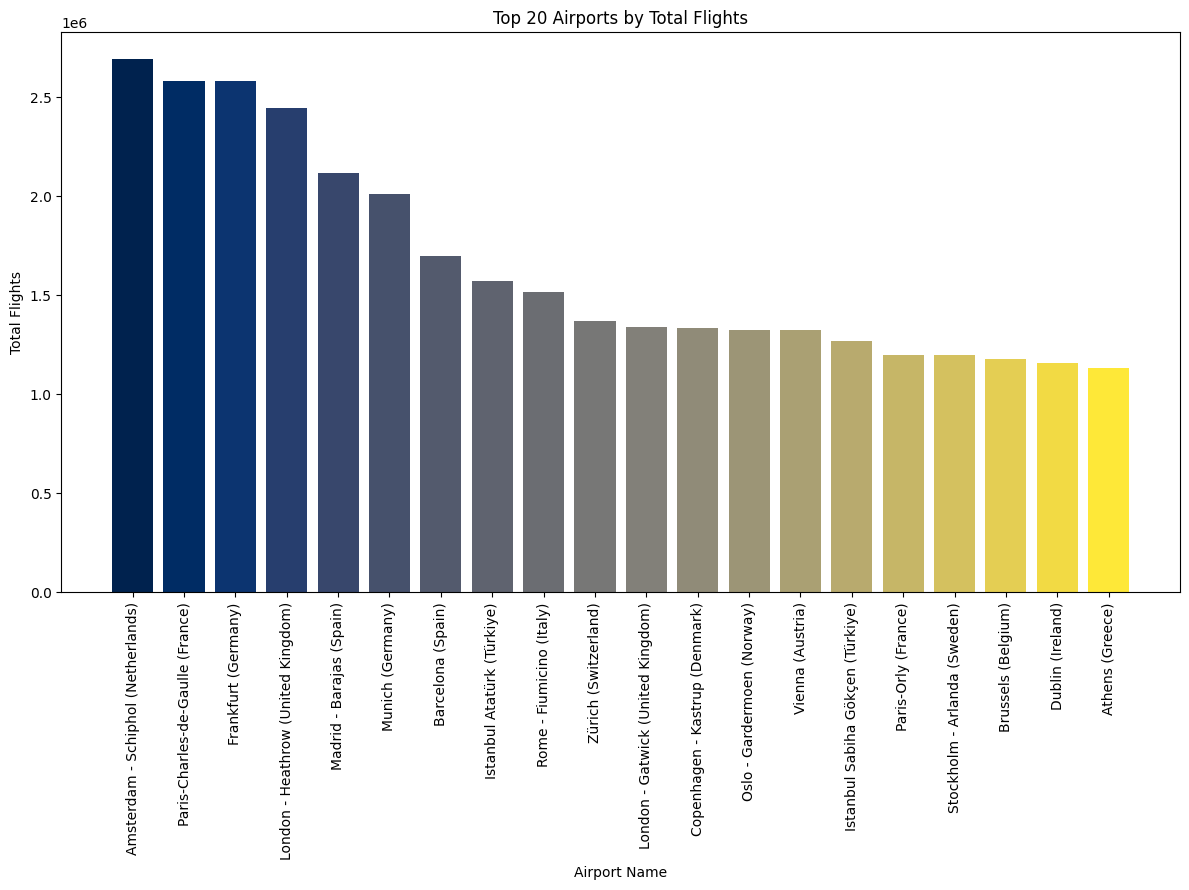

In [37]:
colors = plt.cm.cividis(
    np.linspace(0, 1, 20)
)

plt.figure(figsize=(12, 9))
plt.bar(total_fligths_by_airport.sort_values(ascending=False).head(20).index,
        total_fligths_by_airport.sort_values(ascending=False).head(20).values,
        color=colors)
plt.xticks(rotation=90)
plt.title("Top 20 Airports by Total Flights")
plt.xlabel("Airport Name")
plt.ylabel("Total Flights")
plt.tight_layout()

os.makedirs("plots", exist_ok=True)
filepath = os.path.join("plots", "total_fligths_by_airport.png")
plt.savefig(filepath, dpi=300, bbox_inches="tight", facecolor="white")

### 3.2 Which country has the busiest flight activity?

In [38]:
country_flights = (
    df.groupby("country")["total_flights"]
    .sum()
    .sort_values(ascending=False)
)
country_flights.head(20)

country
Spain             10858755
Germany           10710416
United Kingdom    10571729
France             9980740
Italy              6286032
Türkiye            5680924
Norway             3620616
Netherlands        2958470
Greece             2647744
Switzerland        2371676
Portugal           2257204
Poland             2179193
Belgium            1823046
Sweden             1817112
Austria            1784124
Ireland            1479569
Denmark            1335926
Finland             929047
Czech Republic      819299
Romania             661660
Name: total_flights, dtype: int64

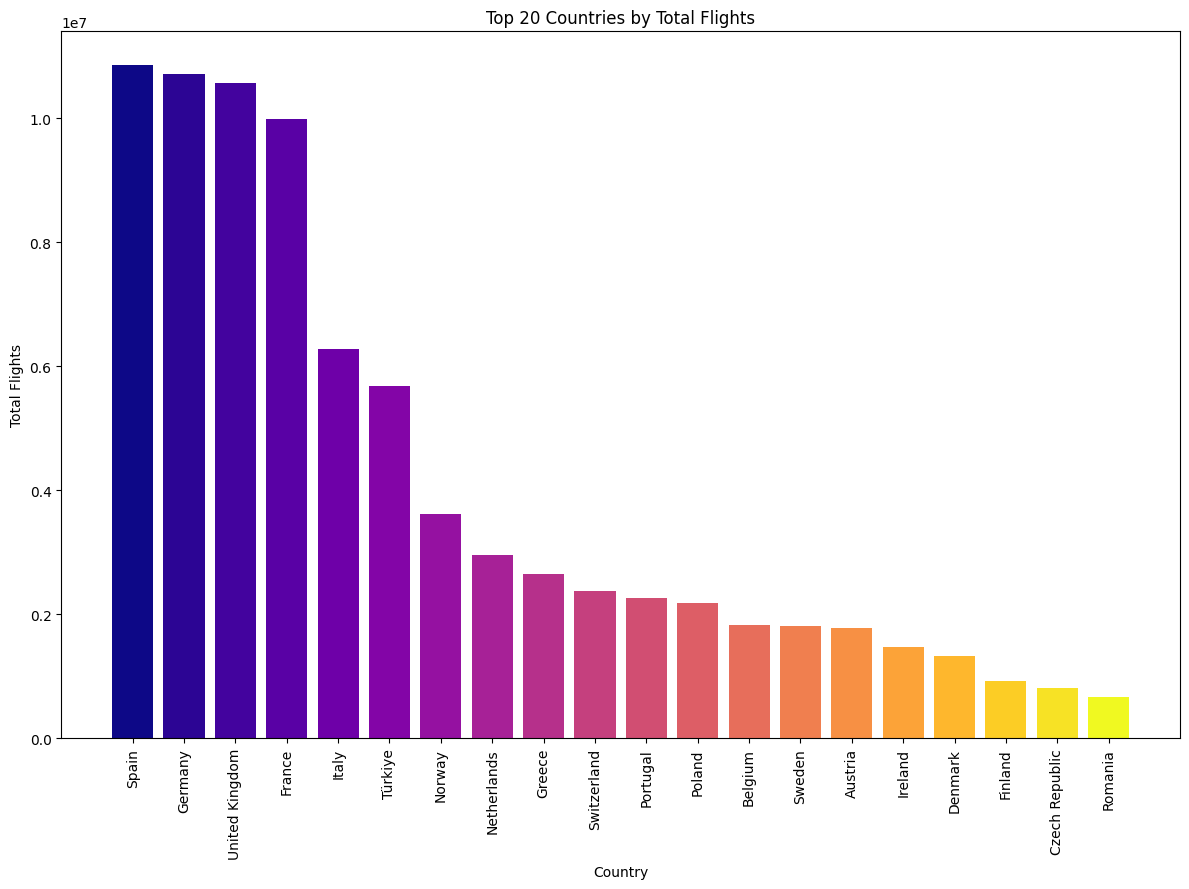

In [39]:
colors = plt.cm.plasma(
    np.linspace(0, 1, 20)
)

plt.figure(figsize=(12, 9))
plt.bar(country_flights.sort_values(ascending=False).head(20).index,
        country_flights.sort_values(ascending=False).head(20).values,
        color=colors)
plt.xticks(rotation=90)
plt.title("Top 20 Countries by Total Flights")
plt.xlabel("Country")
plt.ylabel("Total Flights")
plt.tight_layout()

os.makedirs("plots", exist_ok=True)
filepath = os.path.join("plots", "total_country_flights.png")
plt.savefig(filepath, dpi=300, bbox_inches="tight", facecolor="white")

### 3.3 Which month is the busiest?

In [40]:
month_order = [
    "January", "February", "March",
    "April", "May", "June",
    "July", "August", "September",
    "October", "November", "December"
]

monthly_flights = (
    df.groupby("month_name")["total_flights"]
    .sum()
    .reindex(month_order)
)

monthly_flights

month_name
January      6982208
February     6655653
March        7185807
April        7106667
May          7902728
June         7087768
July         8063220
August       8236009
September    7922637
October      7577217
November     6200505
December     6136119
Name: total_flights, dtype: int64

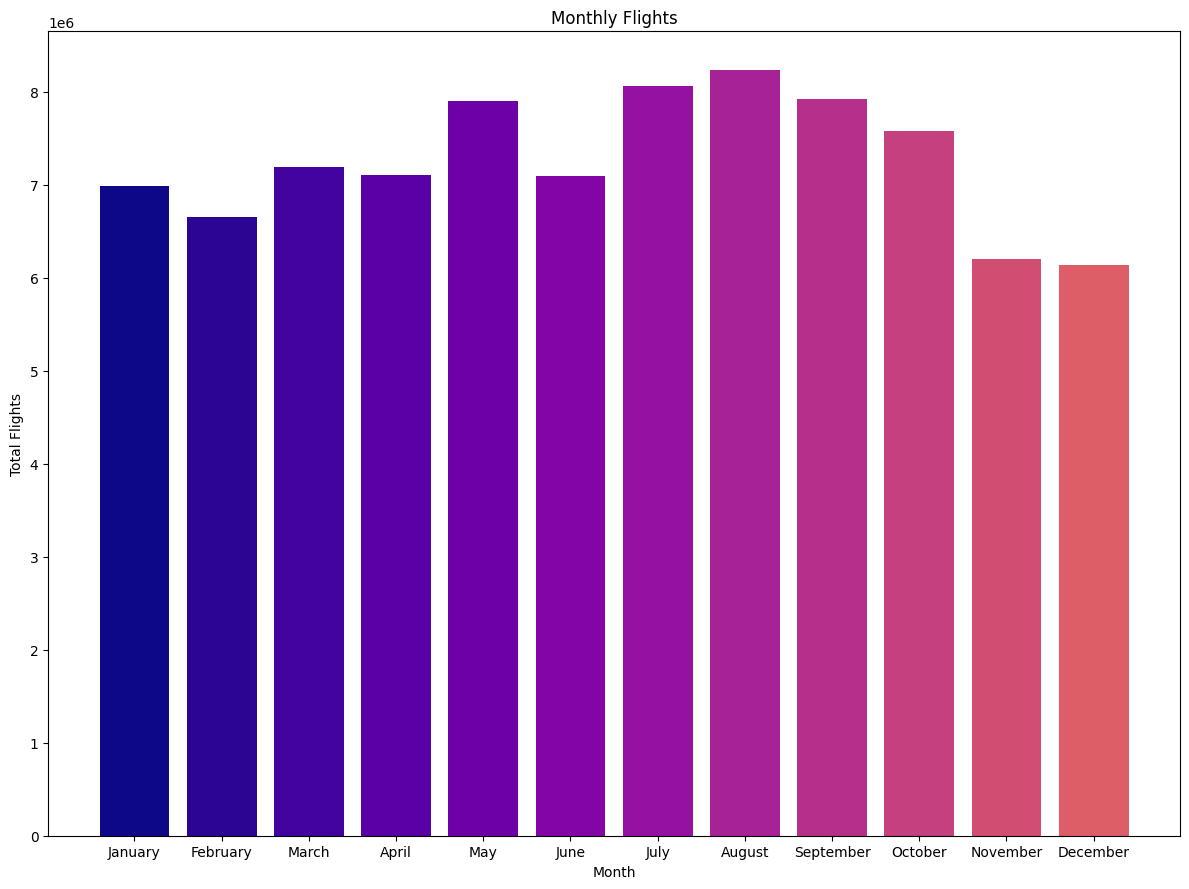

In [41]:
colors = plt.cm.plasma(
    np.linspace(0, 1, 20)
)

plt.figure(figsize=(12, 9))
plt.bar(monthly_flights.index,
        monthly_flights.values,
        color=colors)
# plt.xticks(rotation=45)
plt.title("Monthly Flights")
plt.xlabel("Month")
plt.ylabel("Total Flights")
plt.tight_layout()

os.makedirs("plots", exist_ok=True)
filepath = os.path.join("plots", "monthly_flights.png")
plt.savefig(filepath, dpi=300, bbox_inches="tight", facecolor="white")
plt.ylabel("Total Flights")
plt.tight_layout()

### 3.4 Top 15 Countries Fligth Traffic by Month

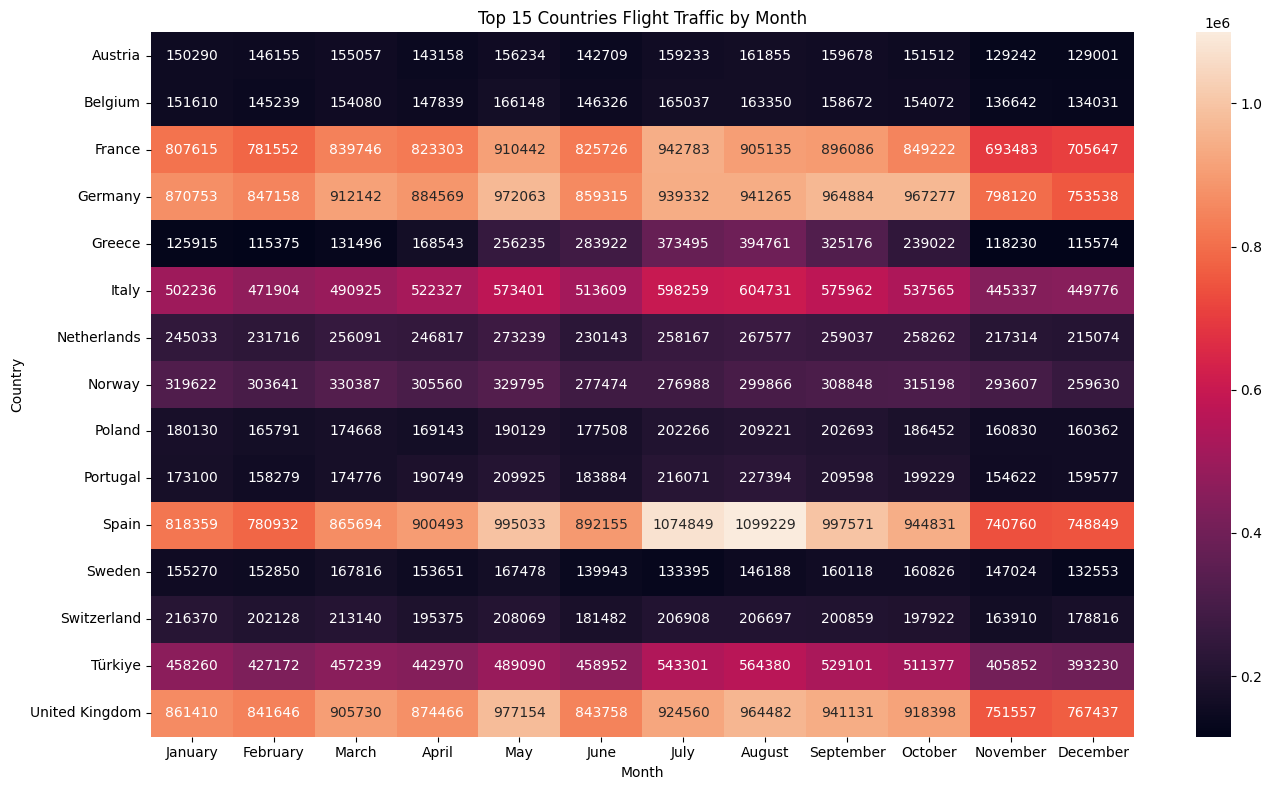

In [43]:
top_15 = (
    df.groupby('country')['total_flights']
    .sum()
    .sort_values(ascending=False)
    .head(15)
    .index
)

filtered_df = df[df['country'].isin(top_15)]

pivot = filtered_df.pivot_table(
    values='total_flights',
    index='country',
    columns='month_name',
    aggfunc='sum'
)

month_order = [
    'January', 'February', 'March',
    'April', 'May', 'June',
    'July', 'August', 'September',
    'October', 'November', 'December'
]

pivot = pivot[month_order]

plt.figure(figsize=(14,8))

sns.heatmap(
    pivot,
    annot=True,
    fmt='.0f'
)

plt.title('Top 15 Countries Flight Traffic by Month')
plt.xlabel('Month')
plt.ylabel('Country')

filepath = os.path.join("plots", "heatmap_country_vs_monthly_flights.png")
plt.savefig(filepath, dpi=300, bbox_inches="tight", facecolor="white")
plt.tight_layout()

### 3.5 Box plot total flights per country

C:\Users\FATHIR\AppData\Local\Temp\ipykernel_32920\4264947578.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(


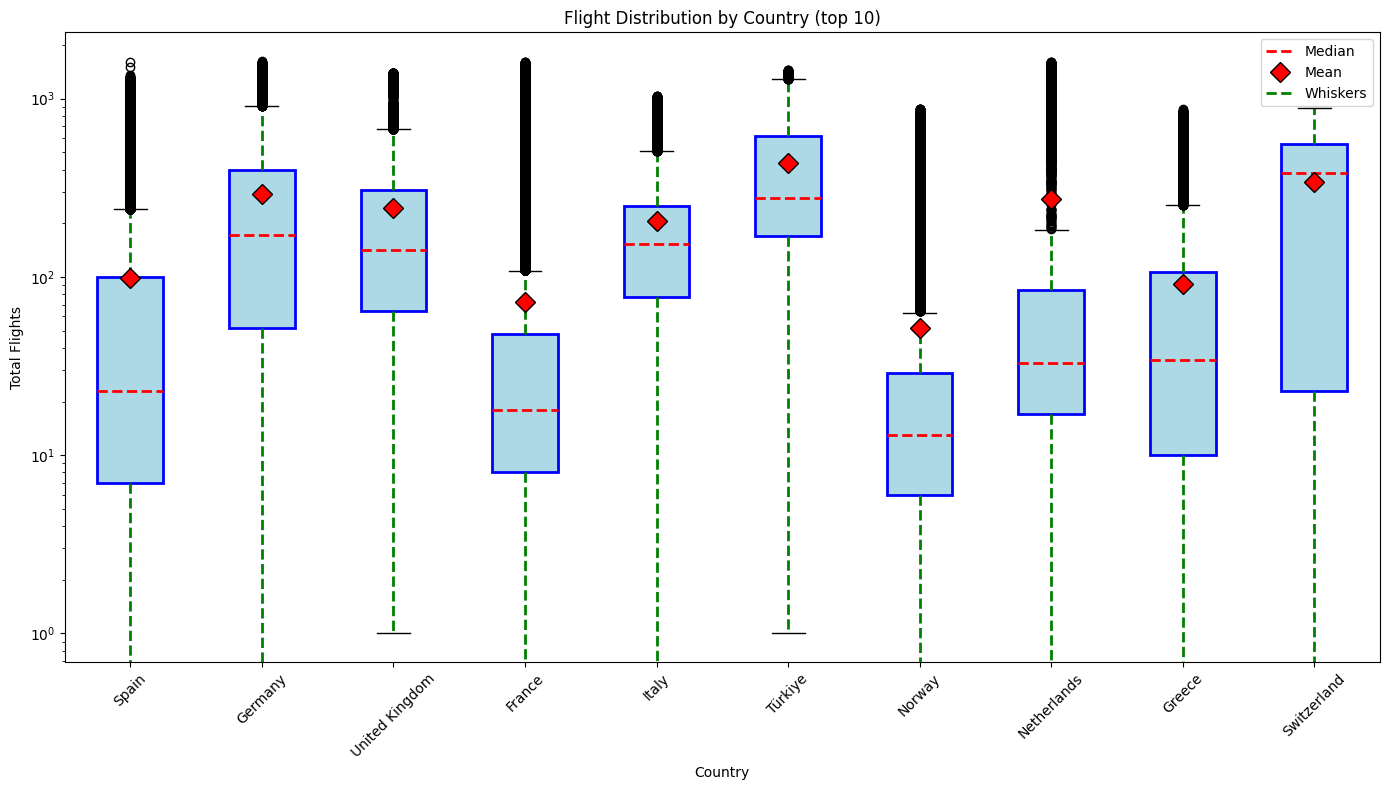

In [73]:
from matplotlib.lines import Line2D

top_10 = (
    df.groupby('country')['total_flights']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

filtered_df = df[df['country'].isin(top_10)]

plt.figure(figsize=(14,8))

box = plt.boxplot(
    [filtered_df[filtered_df['country'] == country]['total_flights'] for country in top_10],
    labels=top_10, patch_artist=True, showmeans=True, medianprops={'color': 'red', 'linewidth': 2, 'linestyle': '--', 'label': 'Median'},
    whiskerprops={'color': 'green', 'linewidth': 2, 'linestyle': '--', 'label': 'Whiskers'}, 
    meanprops={
        "marker" : "D",
        "markerfacecolor" : "red",
        "markeredgecolor" : "black",
        "markersize" : 10,
        "label" : "Mean"
    }
)

legend_elements = [

    Line2D(
        [0],
        [0],
        color='red',
        linestyle='--',
        linewidth=2,
        label='Median'
    ),

    Line2D(
        [0],
        [0],

        marker='D',
        color='white',
        markerfacecolor='red',
        markeredgecolor='black',
        markersize=10,
        label='Mean'
    ),

    Line2D(
        [0],
        [0],
        color='green',
        linestyle='--',
        linewidth=2,
        label='Whiskers'
    )
]

for b in box['boxes']:
    b.set(color='blue', linewidth=2)
    b.set(facecolor='lightblue')

plt.title('Flight Distribution by Country (top 10)')
plt.xlabel('Country')
plt.ylabel('Total Flights')
plt.legend(handles=legend_elements, loc='upper right')
plt.xticks(rotation=45)
plt.yscale('log')
plt.tight_layout()

filepath = os.path.join("plots", "boxplot_country_flight_distribution.png")
plt.savefig(filepath, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()